In [85]:
import numpy as np, importlib
import matplotlib.pyplot as plt
import reach_bib
from reach_bib import *
importlib.reload(reach_bib)
import pickle

# Paraters
D = 50
basis_mat = hamiltonian_generators(D) # basis of generators
p = 0.10 # percent of the generators
nmax = int(p*D**2)
Nsample = 1000

# Initial state
std_basis = np.eye(D) + 1j*np.zeros((D,D)) # standard basis
psi = std_basis[0,:] # initial state

Warray = []
narray = []
for n in range(1,nmax,17):
    narray.append(n)
    v_crit = np.zeros(Nsample,dtype = bool)
    for j in range(Nsample):
        # Final state by random rotation on initial state
        M1 = (np.random.randn(D, D) + 1j * np.random.randn(D, D)) / np.sqrt(2)
        U1, R1 = np.linalg.qr(M1)
        phi = U1 @ psi
        
        # Hamiltonian
        bloch_vec_unary = np.zeros(D**2)
        bloch_vec_unary[:n] = 1 # unary Bloch vector
        bloch_vec = bloch_vec_unary[np.random.permutation(D**2)]# random permutation
        H = (basis_mat @ bloch_vec).reshape(D,D)
        
        # Krylov basis
        V = compute_Krylov_basis(H, psi, D)
        
        # Rank Criterion
        v_crit[j] = np.linalg.matrix_rank(V)  == np.linalg.matrix_rank(np.concatenate([V, phi.reshape(D,1)], axis=1))
    Warray.append(v_crit)
    
    
nfinal = np.array(narray)
Wfinal = np.logical_not(np.array(Warray)).astype(int)

data = [p, nmax, D, nfinal, Wfinal]
datastr = "data_D="+str(D)+"_Nsample="+str(Nsample)
pickle.dump( data, open("data_reach/"+datastr, "wb"))


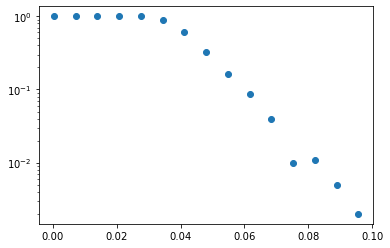

In [86]:
x = np.array(narray)/D**2
v = np.sum(np.logical_not(np.array(Warray)).astype(int),axis=1)/Nsample
plt.semilogy(x,v,"o")



range(1, 41, 3)